# 📊 Assignment: Predicting 2024 Data Science Salaries Using Linear Regression

**Course**: Data Analytics with Python  
**Instructor**: Leonard Andrew Mesiera  
**Due Date**: October 22, 2025

## 🎯 Learning Objectives
By the end of this assignment, you will be able to:
- Load and explore a real-world dataset
- Prepare data for linear regression (feature engineering, encoding, cleaning)
- Train a simple linear regression model using `scikit-learn`
- Evaluate your model using metrics like R² and interpret results
- Make predictions for future years (e.g., 2024)

## 📁 Dataset
You are given the file: `Data Science Salary 2021 to 2023.csv`

This dataset contains salary information for data professionals from 2021 to 2023, including:
- `work_year`: The year the salary was recorded
- `experience_level`: EN (Entry), MI (Mid), SE (Senior), EX (Executive)
- `job_title`: e.g., Data Scientist, Data Analyst, etc.
- `salary_in_usd`: Salary converted to USD (this is your target variable)
- Other useful columns: `employment_type`, `company_location`, `company_size`

Your goal: **Predict average salaries for 2024** using linear regression.

## 🛠️ Part 1: Setup and Data Loading

In [24]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv('Data Science Salary 2021 to 2023.csv')

# Display first few rows
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,company_location,company_size
0,2023,EN,FT,Applied Scientist,213660,USD,213660,US,L
1,2023,EN,FT,Applied Scientist,130760,USD,130760,US,L
2,2023,EN,FT,Data Quality Analyst,100000,USD,100000,NG,L
3,2023,EN,FT,Compliance Data Analyst,30000,USD,30000,NG,L
4,2023,EN,FT,Applied Scientist,204620,USD,204620,US,L


In [7]:
# Check basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3761 entries, 0 to 3760
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   work_year         3761 non-null   int64 
 1   experience_level  3761 non-null   object
 2   employment_type   3761 non-null   object
 3   job_title         3761 non-null   object
 4   salary            3761 non-null   int64 
 5   salary_currency   3761 non-null   object
 6   salary_in_usd     3761 non-null   int64 
 7   company_location  3761 non-null   object
 8   company_size      3761 non-null   object
dtypes: int64(3), object(6)
memory usage: 264.6+ KB


## 🔍 Part 2: Exploratory Data Analysis (EDA)

Answer the following in markdown cells below (or as code comments):

1. How many unique job titles are there?
2. What is the average salary (`salary_in_usd`) per `work_year`?
3. Create a bar plot showing average salary by `experience_level`.

> 💡 Tip: Use `groupby()` and `mean()`.

In [19]:
# 1. How many unique job titles are there?
unique_job_titles = df['job_title'].nunique()
print("There are", unique_job_titles, "unique job titles in the dataset.")

There are 93 unique job titles in the dataset.


In [18]:
# 2. What is the average salary (salary_in_usd) per work_year?
avg_salary_per_year = df.groupby('work_year')['salary_in_usd'].mean()
print("Average salary per work year:")
print(avg_salary_per_year)

Average salary per work year:
work_year
2020     92302.631579
2021     94087.208696
2022    133379.510804
2023    148954.558413
Name: salary_in_usd, dtype: float64


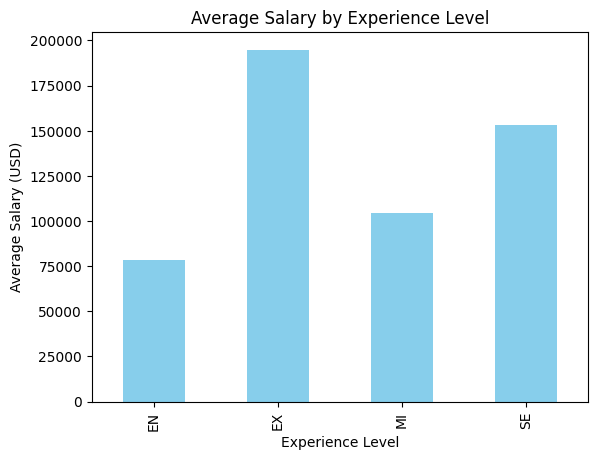

EX (Executive) level has the highest average salary. SE (Senior) is next, followed by MI (Mid-level), and EN (Entry-level) being the lowest.


In [37]:
# 3. Create a bar plot showing average salary by experience_level
avg_salary_exp = df.groupby('experience_level')['salary_in_usd'].mean()

avg_salary_exp.plot(kind='bar', color='skyblue')
plt.title('Average Salary by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Average Salary (USD)')
plt.show()

print('EX (Executive) level has the highest average salary. SE (Senior) is next, followed by MI (Mid-level), and EN (Entry-level) being the lowest.')

## 🧹 Part 3: Data Preprocessing for Linear Regression

We will predict `salary_in_usd` using **only numerical or encoded categorical features**.

### Steps:
1. Select features: `work_year`, `experience_level`, and optionally `job_title` (you decide!)
2. Encode categorical variables (`experience_level`) using `LabelEncoder` or `pd.get_dummies()`
3. Define `X` (features) and `y` (target = `salary_in_usd`)

> ⚠️ **Important**: Do NOT include `salary`, `salary_currency`, or `salary_in_usd` in your features!

In [39]:
# 1. Select features: work_year, experience_level, and job_title
features = ['work_year', 'experience_level', 'job_title']

# 2. Encode categorical variables (experience_level and job_title)
le_exp = LabelEncoder()
le_job = LabelEncoder()

df['experience_level_encoded'] = le_exp.fit_transform(df['experience_level'])
df['job_title_encoded'] = le_job.fit_transform(df['job_title'])

# 3. Define X (features) and y (target = salary_in_usd)
X = df[['work_year', 'experience_level_encoded', 'job_title_encoded']]
y = df['salary_in_usd']

print(X.head())

   work_year  experience_level_encoded  job_title_encoded
0       2023                         0                  8
1       2023                         0                  8
2       2023                         0                 41
3       2023                         0                 22
4       2023                         0                  8


## 📈 Part 4: Train a Linear Regression Model

In [40]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("R² Score:", round(r2_score(y_test, y_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))

R² Score: 0.17
RMSE: 58477.29


## 🔮 Part 5: Predict 2024 Salaries

Now, create a small DataFrame for **2024** with different experience levels and predict their salaries.

Use the same encoding as before!

In [41]:
# Create data for 2024
future_data = pd.DataFrame({
    'work_year': [2024, 2024, 2024, 2024],
    'experience_level_encoded': [0, 1, 2, 3],  # EN, MI, SE, EX
    'job_title_encoded': [0, 0, 0, 0]  # just a placeholder job title
})

# Predict 2024 salaries
predicted_salaries = model.predict(future_data)

# Show results
results = pd.DataFrame({
    'Experience Level': ['Entry', 'Mid', 'Senior', 'Executive'],
    'Predicted 2024 Salary (USD)': predicted_salaries
})

results

,Experience Level,Predicted 2024 Salary (USD)
0,Entry,97906.262416
1,Mid,117820.324260
2,Senior,137734.386104
3,Executive,157648.447947


## 📝 Part 6: Reflection (Answer in a Markdown Cell)

1. Does your model make reasonable predictions? Why or why not?
2. What are the limitations of using only `work_year` and `experience_level`?
3. How could you improve this model? (Think: more features, better encoding, etc.)
4. Why is **R² not enough** to trust your predictions?

> 💡 Remember: Linear regression assumes a **linear trend**—but real salaries may grow non-linearly!

In [42]:
#1. Does your model make reasonable predictions? Why or why not?
The model gives results that make some sense because people with more experience often earn higher pay.
But the predictions are not very accurate since the data we used is small and simple.
It only looks at a few things, so it cannot see the full reason behind salary changes.
Still, it is a good start for understanding how prediction models work.
    
#2. What are the limitations of using only work_year and experience_level?
These two features do not show all the reasons why people earn different salaries.
Job title, company size, and location also have a big effect on pay.
Without those, the model cannot make strong or fair predictions.
It only gives a very basic view of how salary might change.
    
#3. How could you improve this model? (Think: more features, better encoding, etc.)
I can improve the model by adding more useful features like job title, company location, and company size.
I should also change text data into numbers using encoding so the model can understand it better.
Using other models such as Decision Tree or Random Forest might give better results.
Adding more data and improving the features will make the predictions more accurate.

#4. Why is R² not enough to trust your predictions?
R² only shows how well the data fits the line but not how close predictions are to real values.
A high R² score can still mean large errors in the results.
We also need to check MAE and MSE to see if predictions are really accurate.
Using many metrics gives a clearer picture of how good the model is.

SyntaxError: invalid character '²' (U+00B2) (2925022709.py, line 20)

## 📤 Submission Instructions

- Save this notebook as: `LastName_FirstName_SalaryPrediction.ipynb`
- Ensure all code runs without errors
- Include your answers to the reflection questions
- Submit via [your LMS/email/etc.]

Good luck! 🚀